<a href="https://colab.research.google.com/github/angelaportillo/LabPDI_IB/blob/main/P9_LabPDI_Eq5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio de PDI *"Practica 9: Mejorar calidad de imagen a color"*
## Hora: N5 Carrera: IB Brigada: 509
###Integrantes del equipo:
*2028256 Angela Marisa Zapata Portillo*

*2016872 Marian Roxana Martínez Serrato*

*2006071 Gabriela Mariana Rangel Carrillo*


### Docente: Ing. Noe Adiel Ponce Moreno

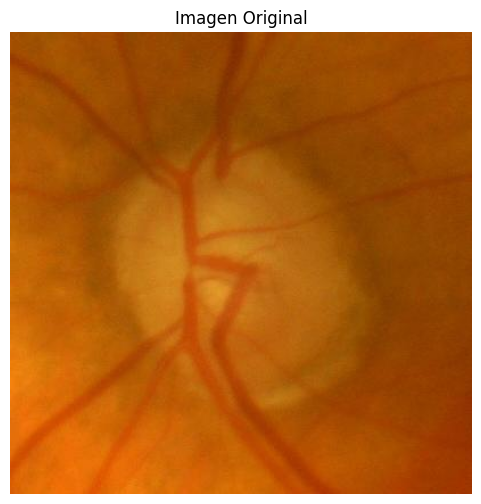

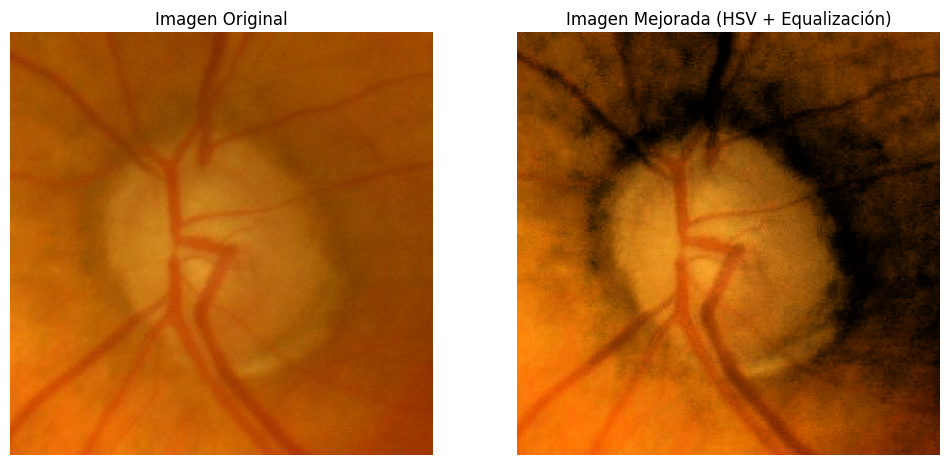

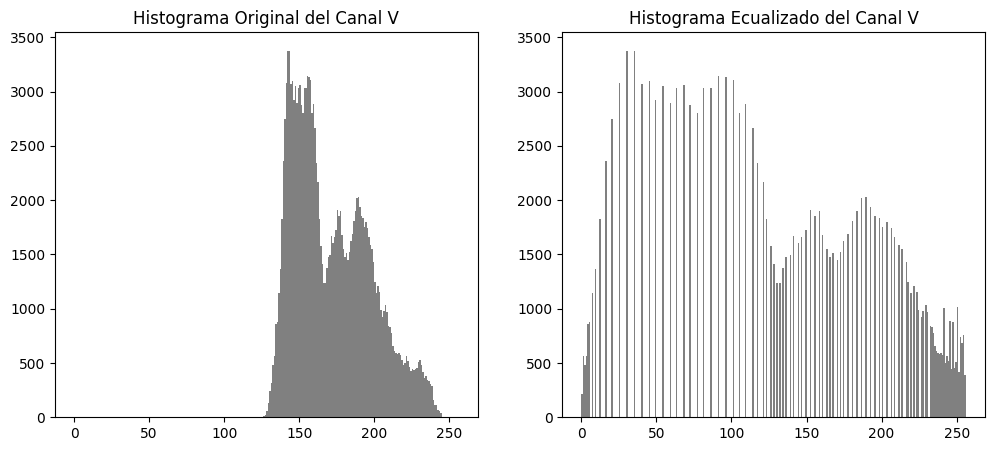

In [1]:
# Importar librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import requests

# ==========================================
# PASO 1: Cargar imagen desde GitHub
# ==========================================

url = "https://raw.githubusercontent.com/dilp90/PDI/main/Imagenes/Im004_ACRIMA.jpg"

# Descargar imagen
img_array = np.asarray(bytearray(requests.get(url).content), dtype=np.uint8)

# Leer imagen con OpenCV
imagen_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# Convertir de BGR a RGB para visualizar correctamente
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Mostrar imagen original
plt.figure(figsize=(6,6))
plt.imshow(imagen_rgb)
plt.title("Imagen Original")
plt.axis("off")
plt.show()

# ==========================================
# PASO 2: Convertir imagen RGB a HSV
# ==========================================

imagen_hsv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2HSV)

# Separar canales H, S y V
H, S, V = cv2.split(imagen_hsv)

# ==========================================
# PASO 3: Ecualizar el canal V (Value)
# ==========================================

V_ecualizado = cv2.equalizeHist(V)

# ==========================================
# PASO 4: Unir nuevamente los canales HSV
# ==========================================

imagen_hsv_ecualizada = cv2.merge((H, S, V_ecualizado))

# ==========================================
# PASO 5: Convertir de HSV a RGB
# ==========================================

imagen_mejorada = cv2.cvtColor(imagen_hsv_ecualizada, cv2.COLOR_HSV2RGB)

# ==========================================
# PASO 6: Mostrar resultados
# ==========================================

plt.figure(figsize=(12,6))

# Imagen original
plt.subplot(1,2,1)
plt.imshow(imagen_rgb)
plt.title("Imagen Original")
plt.axis("off")

# Imagen mejorada
plt.subplot(1,2,2)
plt.imshow(imagen_mejorada)
plt.title("Imagen Mejorada (HSV + Equalización)")
plt.axis("off")

plt.show()

# ==========================================
# PASO 7: Mostrar histogramas del canal V
# ==========================================

plt.figure(figsize=(12,5))

# Histograma original
plt.subplot(1,2,1)
plt.hist(V.ravel(), bins=256, range=[0,256], color='gray')
plt.title("Histograma Original del Canal V")

# Histograma ecualizado
plt.subplot(1,2,2)
plt.hist(V_ecualizado.ravel(), bins=256, range=[0,256], color='gray')
plt.title("Histograma Ecualizado del Canal V")

plt.show()